# 04_概率分布-几何分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊几何分布\~

几何分布用来刻画独立重复伯努利试验中首次成功出现所需的试验次数。

对于刚刚接触的同学来说，理解几何分布不仅能够帮助构建对离散概率分布的直观认识，还能为后续学习其他统计分布打下良好的基础。

### 几何分布基本概念

几何分布描述的是在一次次独立的伯努利试验中，发生“首次成功”之前需要进行多少次试验。我们可以将每次伯努利试验理解为一次“掷硬币”实验，每次试验只有两种可能结果：成功或失败，并且每次试验之间相互独立、成功概率均为 $p$。

举一个简单的例子：假设我们掷一枚偏向正面的硬币，该硬币正面向上的概率为 0.3。几何分布就可以帮助我们估计，平均需要掷多少次硬币才能第一次出现正面？在这种情况下，几何分布就定义了所需的试验次数的概率分布。

### 直观案例分析

#### 案例一：掷硬币

假设一枚硬币正面概率 $p=0.3$，我们希望知道第一次出现正面的试验次数。

- 第一次试验就出现正面的概率为 $0.3$。
- 如果第一次失败（概率 $1-p=0.7$），第二次才出现正面的概率为 $0.7 \times 0.3$。
- 若连续两次失败后第三次成功的概率为 $0.7^2 \times 0.3$。

以此类推，每多尝试一次，前面必须都是失败，而最后一次为成功。

#### 案例二：抽奖问题

设想你在一个抽奖活动中，每次抽奖中奖的概率为 0.1，那么几何分布描述的就是“抽中奖前需要抽多少次”的分布。

- 如果你第一次就中奖，其概率为 $0.1$；
- 如果第一次未中奖，第二次中奖的概率为 $0.9 \times 0.1$；
- 如果前两次都未中奖，第三次中奖的概率为 $0.9^2 \times 0.1$；

这一切都符合几何分布的性质：每次试验都是独立的，每次成功的概率不变，而且“等待”成功出现的次数正好服从几何分布。

### 几何分布的本质及特点

从直观上看，几何分布的本质在于“等待时间”。其核心思想是：在重复进行同一随机试验（成功概率为 $p$）时，第一次成功所花费的试验次数是随机的，并且这种次数正好服从几何分布。

**主要特点：**

1. **离散性**：几何分布是离散型的，因为次数只能是正整数（1，2，3，…）。
2. **内存无记忆性（Memoryless Property）**：几何分布具有无记忆性，这意味着无论已经进行了多少次失败试验，下次成功出现的概率始终与之前的试验次数无关。数学表达为  
$P(X > n+m \mid X > n) = P(X > m)$
3. **递减性**：当试验次数增多时，首次成功的概率会以指数形式递减。
4. **单调性**：在相同条件下，成功概率越大，平均等待的试验次数越少；反之，成功概率较低时，等待的试验次数会增多。
5. **参数单一**：几何分布只依赖一个参数 $p$（成功概率），使得其计算和应用较为简单。

## 公式推导

在数学上，对几何分布的主要研究内容集中在其概率质量函数（PMF）、累计分布函数（CDF）及其各项统计量（如均值、方差、矩母函数）的推导。

### 概率质量函数的推导

设随机变量 $X$表示首次成功试验的次数，则 $X$的概率质量函数 $P(X=k)$定义为：在前 $k-1$次试验均为失败，而第 $k$次试验成功的概率。

记每次成功的概率为 $p$，则每次失败的概率为 $1-p$。因此有：  
$P(X=k) = (1-p)^{k-1} \cdot p, \quad k=1,2,3,\ldots$

**推导过程说明：**

- 第一次试验成功的概率为 $p$；
- 如果第 $k$次试验成功，那么前 $k-1$次必须全部失败，其概率为 $(1-p)^{k-1}$；
- 由于试验相互独立，上述事件的联合概率即为 $(1-p)^{k-1}\cdot p$。

### 累积分布函数的推导

几何分布的累计分布函数（CDF）定义为：


$$
F(k)=P(X\leq k)= \sum_{i=1}^{k} P(X=i)=\sum_{i=1}^{k} (1-p)^{i-1} \cdot p
$$


利用等比数列求和公式：


$$
\sum_{i=0}^{k-1} q^i = \frac{1-q^{k}}{1-q}
$$


其中 $q=1-p$。

因此，将求和公式从 $i=1$转换为 $i=0$得：


$$
F(k)=p \sum_{i=0}^{k-1} (1-p)^{i} = p\cdot \frac{1-(1-p)^k}{1-(1-p)} = 1-(1-p)^k.
$$


### 均值的推导

为了推导几何分布的数学期望 $E(X)$，即首次成功试验的平均次数，我们有：


$$
E(X)=\sum_{k=1}^{\infty}k\cdot P(X=k)=\sum_{k=1}^{\infty}k(1-p)^{k-1}p.
$$


利用求和公式，已知：


$$
\sum_{k=1}^{\infty}kx^{k-1}=\frac{1}{(1-x)^2}, \quad |x|<1.
$$


令 $x=1-p$（满足 $|1-p|<1$），则：


$$
E(X)=p\cdot \frac{1}{p^2}=\frac{1}{p}.
$$


这表明如果成功概率为 $p$，则平均需要 $\frac{1}{p}$次试验才会出现第一次成功。

### 方差的推导

几何分布的方差 $\mathrm{Var}(X)$定义为：


$$
\mathrm{Var}(X)=E(X^2)-[E(X)]^2.
$$


首先需要计算 $E(X^2)$：


$$
E(X^2)=\sum_{k=1}^{\infty}k^2(1-p)^{k-1}p.
$$


利用已知的级数求和公式：


$$
\sum_{k=1}^{\infty}k^2x^{k-1}=\frac{1+x}{(1-x)^3}, \quad |x|<1.
$$


令 $x=1-p$可得：


$$
E(X^2)=p\cdot \frac{1+(1-p)}{p^3}=p\cdot \frac{2-p}{p^3}=\frac{2-p}{p^2}.
$$


因此，方差为：


$$
\mathrm{Var}(X)=\frac{2-p}{p^2}-\left(\frac{1}{p}\right)^2=\frac{2-p-1}{p^2}=\frac{1-p}{p^2}.
$$


### 无记忆性性质的证明

几何分布具有“无记忆性”，即满足：


$$
P(X>n+m \mid X>n)=P(X>m),
$$


证明思路如下：

设 $X$为第一次成功的试验次数，则：


$$
P(X>n)=1-P(X\le n)=1-[1-(1-p)^n]=(1-p)^n.
$$


因此，


$$
P(X>n+m \mid X>n)=\frac{P(X>n+m)}{P(X>n)}=\frac{(1-p)^{n+m}}{(1-p)^n}=(1-p)^m=P(X>m).
$$


这一结果证明了：已知前 $n$次均为失败之后，再等待 $m$次而成功的概率，与从起始时刻等待 $m$次成功的概率相同，也即几何分布是无记忆的。

### 矩母函数（MGF）的推导

矩母函数是研究分布其他性质的重要工具。几何分布的矩母函数 $M_X(t)$定义为：


$$
M_X(t)=E(e^{tX})=\sum_{k=1}^{\infty}e^{tk}P(X=k)=\sum_{k=1}^{\infty}e^{tk}(1-p)^{k-1}p.
$$


令 $u=e^{t}(1-p)$，则有：


$$
M_X(t)=pe^{t}\sum_{k=1}^{\infty} u^{k-1} = pe^{t}\cdot \frac{1}{1-u}, \quad \text{当}\ |u|<1.
$$


因此，


$$
M_X(t)=\frac{pe^{t}}{1-e^{t}(1-p)}.
$$


这个矩母函数对于计算任意矩以及分析分布的其他统计性质非常有用。

## Python实现

接下来通过 Python 代码的实现，直观展示如何生成几何分布数据、绘制概率质量函数图，并结合一个简单的机器学习示例，聊聊几何分布的实际应用\~

### 使用 Python 模拟几何分布数据

我们可以使用 NumPy 随机数模块生成服从几何分布的随机数据，也可以利用 SciPy 库中的几何分布函数进行概率计算与可视化。

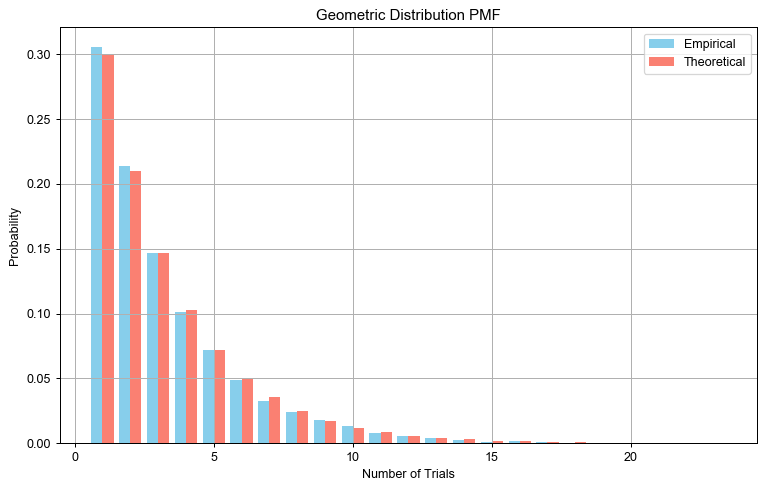

Empirical Mean: 3.2706
Theoretical Mean: 3.3333333333333335
Empirical Variance: 7.38017564
Theoretical Variance: 7.777777777777778


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

# 设置随机种子以保证结果可复现
np.random.seed(42)

# 设置成功概率 p
p = 0.3

# 生成服从几何分布的随机数据（表示试验次数）
num_samples = 10000
data = np.random.geometric(p, size=num_samples)

# 统计各试验次数出现的频率
max_trial = data.max()
trials = np.arange(1, max_trial+1)
frequency = np.array([np.sum(data == k) for k in trials])
probability_empirical = frequency / num_samples

# 计算理论概率
probability_theoretical = geom.pmf(trials, p)

plt.figure(figsize=(10, 6))
plt.bar(trials - 0.2, probability_empirical, width=0.4, label='Empirical', color='skyblue')
plt.bar(trials + 0.2, probability_theoretical, width=0.4, label='Theoretical', color='salmon')
plt.xlabel('Number of Trials')     
plt.ylabel('Probability')          
plt.title('Geometric Distribution PMF')  
plt.legend()
plt.grid(True)
plt.show()

# 输出均值和方差，对比理论值
empirical_mean = np.mean(data)
empirical_var = np.var(data)
theoretical_mean = 1 / p
theoretical_var = (1 - p) / (p ** 2)

print("Empirical Mean:", empirical_mean)
print("Theoretical Mean:", theoretical_mean)
print("Empirical Variance:", empirical_var)
print("Theoretical Variance:", theoretical_var)

- **数据生成**：代码中使用 `np.random.geometric(p, size=num_samples)` 来生成样本数据，每个数据点代表一次实验中第一次成功所需的试验次数。
- **概率计算**：通过统计生成数据中每个试验次数出现的频率，可以得到经验概率，并与 SciPy 中 `geom.pmf` 得到的理论概率进行比较。
- **图形展示**：使用 matplotlib 绘制两个柱状图，分别表示经验概率（Empirical）和理论概率（Theoretical），其中 X 轴标签为 "Number of Trials"，Y 轴标签为 "Probability"，图表标题为 "Geometric Distribution PMF"。
- **统计量计算**：通过计算数据的均值与方差，并与公式 $E(X)=\frac{1}{p}$和 $\mathrm{Var}(X)=\frac{1-p}{p^2}$对比，验证几何分布的基本统计性质。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

### 几何分布在机器学习中的应用

在机器学习中，几何分布常用于建模等待时间、事件发生的间隔或作为先验分布的一部分。以下给出一个简单示例：基于几何分布模拟广告点击率问题，并用该分布分析用户首次点击广告前需要浏览广告的次数，从而进一步用于模型预测。

#### 案例：广告点击预测模型

假设我们有一个在线广告平台，希望通过用户浏览多次广告之后最终发生点击的次数来判断点击概率。这里可将用户点击看作一次 Bernoulli 试验成功，用户每次浏览广告都是一次独立试验，成功点击的概率为 $p$（假设为0.1）。我们可以利用几何分布模拟：

- 用户第一次点击广告前浏览广告的次数；
- 分析不同用户群体的点击行为，从而在后续的模型中作为输入特征之一，用于广告投放策略或用户行为预测。

#### 应用流程

1. **数据生成**：使用几何分布生成模拟数据，表示用户在成功点击前浏览广告的次数。
2. **特征工程**：将生成的浏览次数作为特征之一，结合其他用户行为数据（如停留时间、浏览深度、点击频率等）构建用户画像。
3. **模型建立**：选择分类模型或回归模型对用户点击行为进行预测；例如，利用逻辑回归预测用户点击的概率，或者使用随机森林等集成方法。
4. **模型评估与调整**：根据预测效果调整模型参数或特征工程步骤，提升点击率预测准确性。

利用几何分布生成数据，并将其作为特征输入到逻辑回归模型中进行点击预测。注意，此示例为模拟生成数据，并非真实业务数据，仅供理解应用流程之用。

数据样本：
   num_ad_views  avg_stay_time  click
0             4       4.522608      1
1            21       5.872696      0
2             9       8.571384      0
3             2       5.066967      1
4             2       4.647483      1

特征描述统计：
       num_ad_views  avg_stay_time        click
count   5000.000000    5000.000000  5000.000000
mean       9.913200       5.030926     0.417400
std        9.490652       2.013184     0.493179
min        1.000000      -3.103831     0.000000
25%        3.000000       3.710094     0.000000
50%        7.000000       5.058978     0.000000
75%       13.000000       6.368914     1.000000
max       94.000000      12.128648     1.000000

逻辑回归模型的预测准确率： 1.0

分类报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       902
           1       1.00      1.00      1.00       598

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00    

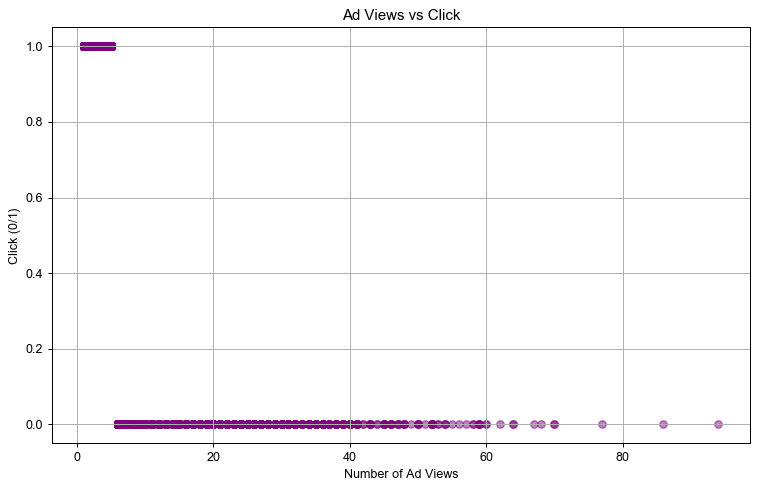

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import geom
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 模拟参数
p_click = 0.1  # 单次广告点击的概率
num_users = 5000  # 模拟用户数量

# 为每个用户生成一个几何分布数据，表示用户首次点击广告前浏览广告的次数
np.random.seed(2023)
num_ad_views = np.random.geometric(p_click, size=num_users)

# 构造其他虚拟特征（例如用户在站内停留的时长，随机生成）
avg_stay_time = np.random.normal(loc=5, scale=2, size=num_users)  # 单位：分钟
# 构造模拟点击标签：假设浏览广告次数少于某个阈值的用户更有可能点击广告
click_threshold = np.percentile(num_ad_views, 40)
labels = (num_ad_views <= click_threshold).astype(int)

# 构造 DataFrame 存放特征和标签
data_ml = pd.DataFrame({
    'num_ad_views': num_ad_views,
    'avg_stay_time': avg_stay_time,
    'click': labels
})

# 数据探索
print("数据样本：")
print(data_ml.head())
print("\n特征描述统计：")
print(data_ml.describe())

# 特征和标签划分
X = data_ml[['num_ad_views', 'avg_stay_time']]
y = data_ml['click']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 建立逻辑回归模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 进行预测
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\n逻辑回归模型的预测准确率：", accuracy)
print("\n分类报告：")
print(classification_report(y_test, y_pred))

# 可视化展示不同特征对点击率的影响（这里展示 num_ad_views 与点击情况的关系）
plt.figure(figsize=(10, 6))
plt.scatter(data_ml['num_ad_views'], data_ml['click'], alpha=0.5, color='purple')
plt.xlabel('Number of Ad Views')   
plt.ylabel('Click (0/1)')            
plt.title('Ad Views vs Click')       
plt.grid(True)
plt.show()

- **数据生成与构造**：

  - 使用 `np.random.geometric(p_click, size=num_users)` 生成每个用户在成功点击前浏览广告的次数，将该特征视作用户点击行为的重要变量。
  - 同时，生成用户在站内停留时长（正态分布模拟），构造其他可能影响点击的因素。
- **标签构造**：

  - 此处通过简单的规则：当用户浏览广告次数低于总体分布的 40% 分位数时，认为其点击概率较高，将其标签设为 1（点击），其他设为 0（未点击）。
  - 这种简单规则仅用于模拟，真实模型中可能需要更多复杂的特征组合。
- **模型训练**：

  - 划分训练集与测试集，利用逻辑回归模型（sklearn 中的 LogisticRegression）进行训练与预测。
  - 输出模型预测准确率和分类报告，检验特征在点击预测中的作用。
- **结果展示**：

  - 通过散点图直观展示了用户浏览广告次数与点击情况之间的关系，X 轴为 "Number of Ad Views"，Y 轴为 "Click (0/1)"。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

我们可以看到如何利用几何分布的模拟数据进行数据生成及特征构造，并进一步引入机器学习算法（如逻辑回归）进行预测分析。几何分布在此案例中帮助描述了用户“等待”点击广告的行为，其无记忆性及形态特征使得该分布在处理离散型等待时间数据时非常有用。

### 实际思考

为什么选择几何分布进行建模？

在很多实际场景中，事件的发生过程往往遵循独立重复试验的模式。

举例来说，不论是用户点击广告、制造过程中零件的合格情况，还是设备故障前的连续运行时间，都可以近似认为是伯努利试验。如果事件发生有一定的概率 $p$，那么等待第一次成功发生的时间（或次数）往往符合几何分布。

选择几何分布建模的原因主要有以下几点：

1. **简洁性**：几何分布仅包含一个参数 $p$，易于理解和实现。
2. **适用性**：在许多实际应用中，事件发生具有随机性和无记忆性，几何分布很好地契合这一特性。
3. **数学性质优良**：其概率质量函数、均值、方差及矩母函数皆有明确的解析式，使得理论分析和数值计算较为方便。

### 从理论到实践的转变

在将理论概率分布应用到实际问题建模时，需要经过以下几个步骤：

1. **假设检验**：在实际数据中检验假设：事件是否服从独立重复的伯努利试验？
2. **参数估计**：根据已有数据估计成功概率 $p$；通常可以采用极大似然估计方法，理论上，样本中成功次数与试验次数的比例可以估计 $p$的值。
3. **模型拟合**：利用几何分布的理论特性，对数据进行模型拟合，并通过统计检验（如卡方检验）确认拟合的优劣。
4. **应用到预测**：将拟合好的分布用于预测，如在广告点击预测中，结合几何分布的先验知识与其他特征，构建机器学习模型，提高预测准确性。

### 几何分布与其他分布的比较

在概率论中，除了几何分布外，还有许多其他常见的离散分布，如二项分布、负二项分布、泊松分布等。几何分布与负二项分布之间具有密切关系：

- 几何分布是负二项分布的一种特殊情况，当目标是第一次成功时（即成功次数为 1），几何分布就相当于负二项分布。
- 与二项分布不同，二项分布描述的是在固定试验次数内成功出现的次数，而几何分布关注的是固定成功次数下试验的次数。

在实际应用中，需要根据问题背景选择合适的分布进行建模。例如：

- 对于需要知道在固定试验次数内成功次数的场景，适合使用二项分布；
- 对于需要描述连续失败次数直到达到固定成功次数的场景，则用负二项分布较好；
- 而描述首次成功的等待时间，则几何分布最为合适。

通过前文的详细介绍，我们可以归纳几点关键结论：

- **直观理解**：几何分布描述的是在一系列独立的伯努利试验中，首次成功出现所需的试验次数；该分布具备无记忆性、递减性等特点。
- **数学推导**：通过对概率质量函数、累计分布函数、均值、方差以及矩母函数的推导，展示了几何分布严谨的数学结构，这为后续更深入的统计分析提供了理论依据。
- **Python 实现**：利用 Python 进行数据模拟与可视化，不仅可以直观比较理论分布与实际数据之间的一致性，还可以基于几何分布构造机器学习模型，应用于实际问题（例如广告点击预测）。
- **应用拓展**：几何分布在贝叶斯推断、生成模型以及强化学习中均有广泛应用，其独特的无记忆性特点使得其能够适应多种实际场景，为复杂系统建模提供简单而直观的工具。

未来，结合多个概率分布对复杂现象进行更精确的建模将成为研究重点。几何分布作为这些分布中的一种，由于其数学简单、理论清晰，仍将在许多工程和科研领域中占据重要位置。由此，我们建议在应用中根据实际问题灵活选用合适的分布模型，不排除在几何分布的基础上进行扩展，如混合几何分布、多参数模型等方向进行深入研究。